In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.linear_model import Lasso, OrthogonalMatchingPursuit
from sklearn.decomposition import DictionaryLearning
from sklearn.preprocessing import StandardScaler

In [2]:
# ======================================================
# 1. LOAD DATA
# ======================================================

X_emb = np.load("./data/mnist_emb_model1.npy")  # (N, d)
X_emb = StandardScaler().fit_transform(X_emb)
X_emb = X_emb[:2000].T  # -> (d, N)

d, N = X_emb.shape
n_atoms = 256
device = "cuda" if torch.cuda.is_available() else "cpu"

print("Data shape:", X_emb.shape)

Data shape: (128, 2000)


In [3]:
X_emb[0, :].mean()

np.float32(0.018429609)

In [4]:
# ======================================================
# 2. INITIAL DICTIONARY
# ======================================================

def normalize_columns(D):
    return D / (np.linalg.norm(D, axis=0, keepdims=True) + 1e-8)

D_init = normalize_columns(np.random.randn(d, n_atoms))

In [5]:
def compute_metrics(X, D, R, name=""):
    X_hat = D @ R  # (d, N)

    errors = (
        np.linalg.norm(X - X_hat, axis=0) /
        np.linalg.norm(X, axis=0)
    ) * 100

    sparsity = np.sum(np.abs(R) > 1e-4, axis=0)
    sparsity_ratio = np.mean(np.abs(R) > 1e-4)

    print(f"\n===== {name} =====")
    print(f"Avg error: {errors.mean():.4f}")
    print(f"Std error: {errors.std():.4f}")
    print(f"Avg sparsity: {sparsity.mean():.2f}")
    print(f"Sparsity ratio: {sparsity_ratio:.4f}")

    return errors, sparsity


In [6]:
import torch
import numpy as np
from utils import SingleUserADMMDict


# ----------------------------
# Synthetic data
# ----------------------------
np.random.seed(0)
torch.manual_seed(0)

d = X_emb.shape[0]
n = X_emb.shape[1]
K = int(X_emb.shape[0] * 3.0)
k_sparsity = int(d * 0.1)


# ----------------------------
# Train model
# ----------------------------
model = SingleUserADMMDict(
    d=d,
    K=K,
    k_sparsity=k_sparsity,
    rho=5,
    admm_iters=30
)

X_emb_tensor = torch.from_numpy(X_emb).float()


D_hat, S_hat, losses = model.fit(X_emb_tensor, outer_iters=100)


# ----------------------------
# Evaluation
# ----------------------------
print("\nFinal loss:", losses[-1])

print("\nSparsity check (active atoms):")
active = torch.sum(torch.norm(S_hat, dim=1) > 1e-6).item()
print("Active atoms:", active, "/", K)


iter 0: loss=366.539307
iter 1: loss=48.126644
iter 2: loss=38.136490
iter 3: loss=36.849434
iter 4: loss=36.439434
iter 5: loss=36.206329
iter 6: loss=36.039795
iter 7: loss=35.907288
iter 8: loss=35.793858
iter 9: loss=35.696091
iter 10: loss=35.612843
iter 11: loss=35.543015
iter 12: loss=35.485977
iter 13: loss=35.440338
iter 14: loss=35.404224
iter 15: loss=35.375332
iter 16: loss=35.352177
iter 17: loss=35.333340
iter 18: loss=35.317970
iter 19: loss=35.305294
iter 20: loss=35.294498
iter 21: loss=35.285511
iter 22: loss=35.277710
iter 23: loss=35.270576
iter 24: loss=35.264496
iter 25: loss=35.259186
iter 26: loss=35.254246
iter 27: loss=35.249676
iter 28: loss=35.245735
iter 29: loss=35.242065
iter 30: loss=35.238636
iter 31: loss=35.235279
iter 32: loss=35.232384
iter 33: loss=35.229889
iter 34: loss=35.227287
iter 35: loss=35.224972
iter 36: loss=35.222878
iter 37: loss=35.220787
iter 38: loss=35.219040
iter 39: loss=35.217205
iter 40: loss=35.215500
iter 41: loss=35.214012
i

In [ ]:
print((D_hat.T @ D_hat).sum())
print(k_sparsity)

In [ ]:

eps = 1e-4

row_nnz = torch.sum(torch.abs(S_hat) > eps, dim=1)
row_sparsity_ratio = row_nnz.float() / S_hat.shape[1]
print(torch.sum(row_nnz > 0))
print(torch.sum(row_sparsity_ratio))

In [6]:

X_np = X_emb_tensor.detach().cpu().numpy()
D_np = D_hat.detach().cpu().numpy()
R_np = S_hat.detach().cpu().numpy()

errors, sparsity = compute_metrics(
    X_np,
    D_np,
    R_np,
    name="Admm"
)


NameError: name 'X_emb_tensor' is not defined

In [ ]:

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# Sparse codes
im0 = axes[0].imshow(R_np, aspect="auto", cmap="viridis")
axes[0].set_title("R (Sparse Codes)")
axes[0].set_xlabel("Samples")
axes[0].set_ylabel("Atoms")
plt.colorbar(im0, ax=axes[0])



In [ ]:
def create_correlated_datasets(X_base, n_users=3, n_total=200, n_shared=100):
    """
    Create correlated datasets by sharing columns with random permutation.

    X_base: (n_samples, d) numpy or torch
    Returns: dict {i: (d x n_total)}
    """

    if isinstance(X_base, np.ndarray):
        X_base = torch.tensor(X_base).float()

    N, d = X_base.shape

    # --- Step 1: pick shared pool ---
    shared_idx = torch.randperm(N)[:n_shared]
    X_shared = X_base[shared_idx]   # (n_shared, d)

    X_dict = {}

    for i in range(n_users):

        # --- Step 2: permute shared columns differently per user ---
        perm = torch.randperm(n_shared)
        X_shared_i = X_shared[perm]

        # --- Step 3: sample private data ---
        private_idx = torch.randperm(N)[:(n_total - n_shared)]
        X_private = X_base[private_idx]

        # --- Step 4: concatenate ---
        X_i = torch.cat([X_shared_i, X_private], dim=0)  # (n_total, d)

        # --- Step 5: shuffle columns globally ---
        shuffle = torch.randperm(n_total)
        X_i = X_i[shuffle]

        # --- Step 6: transpose to (d x n) ---
        X_dict[i] = X_i.T.contiguous()

    return X_dict

In [6]:
data_dir = "./data/"
X1 = np.load(data_dir + "mnist_emb_model1.npy")
X2 = np.load(data_dir + "mnist_emb_model2.npy")
X3 = np.load(data_dir + "mnist_emb_model3.npy")


#X_1 = StandardScaler().fit_transform(X1)
#X_1 = X_1  # -> (d, N)
#X_2 = StandardScaler().fit_transform(X2)
#X_2 = X_2  # -> (d, N)
#X_3 = StandardScaler().fit_transform(X3)
#X_3 = X_3  # -> (d, N)

norm = np.linalg.norm(X1, axis=0, keepdims=True)   # shape (1, n)
X_1 = X1 / norm
norm = np.linalg.norm(X2, axis=0, keepdims=True)   # shape (1, n)
X_2 = X2 / norm
norm = np.linalg.norm(X3, axis=0, keepdims=True)   # shape (1, n)
X_3 = X3 / norm


d, N = X_1.shape
K = int(X_1.shape[0] * 3.0)
k_sparsity = int(d * 0.1)

print(f"d: {d}, N: {N}, K: {K}, k_sparsity: {k_sparsity}")
print("Data shape:", X_1.shape, X_2.shape, X_3.shape)



X_dict = {
    0: torch.tensor(X_1.T).float(),  # (d x n)
    1: torch.tensor(X_2.T).float(),
    2: torch.tensor(X_3.T).float()
}
""" 
X_dict = create_correlated_datasets(
    X_base=X_1,   # your original dataset
    n_users=3,
    n_total=d,
    n_shared=50   # 40% shared
)
 """

d: 60000, N: 128, K: 180000, k_sparsity: 6000
Data shape: (60000, 128) (60000, 128) (60000, 128)


' \nX_dict = create_correlated_datasets(\n    X_base=X_1,   # your original dataset\n    n_users=3,\n    n_total=d,\n    n_shared=50   # 40% shared\n)\n '

In [ ]:
M = (X_dict[0] @ X_dict[1].T) / N

plt.figure(figsize=(6, 5))
plt.imshow(M, cmap='viridis', aspect='auto')
plt.colorbar(label='Value')
plt.title("Matrix M = (X₁ᵀ X₂) / N")
plt.xlabel("Columns")
plt.ylabel("Rows")
plt.show()

In [ ]:
from utils import MultiUserADMMDict

d = X1.shape[1]   # embedding dimension
K = int(X_emb.shape[0] * 2.0)           # number of atoms
k_sparsity = int(d * 0.9)   # number of active atoms

model = MultiUserADMMDict(
    d=d,
    K=n_atoms,
    k_sparsity=k_sparsity,
    rho=1.0,
    admm_iters=30
)

In [ ]:
D, S_list, losses = model.fit(X_dict, outer_iters=100)

In [ ]:
X_np = X_dict[2].detach().cpu().numpy()
D_np = D.detach().cpu().numpy()
R_np = S_list[2].detach().cpu().numpy()

errors, sparsity = compute_metrics(
    X_np,
    D_np,
    R_np,
    name="Admm"
)

In [ ]:

eps = 1e-4

row_nnz = torch.sum(torch.abs(S_list[2]) > eps, dim=1)
row_sparsity_ratio = row_nnz.float() / S_list[2].shape[1]
print(torch.sum(row_nnz > 0))
print(torch.sum(row_sparsity_ratio))

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Sparse codes
im0 = axes[0].imshow(S_list[0].detach().cpu().numpy(), aspect="auto", cmap="viridis")
axes[0].set_title("R (Sparse Codes)")
axes[0].set_xlabel("Samples")
axes[0].set_ylabel("Atoms")
plt.colorbar(im0, ax=axes[0])

# Sparse codes
im1 = axes[1].imshow(S_list[1].detach().cpu().numpy(), aspect="auto", cmap="viridis")
axes[1].set_title("R (Sparse Codes)")
axes[1].set_xlabel("Samples")
axes[1].set_ylabel("Atoms")
plt.colorbar(im1, ax=axes[1])


# Sparse codes
im2 = axes[2].imshow(S_list[2].detach().cpu().numpy(), aspect="auto", cmap="viridis")
axes[2].set_title("R (Sparse Codes)")
axes[2].set_xlabel("Samples")
axes[2].set_ylabel("Atoms")
plt.colorbar(im2, ax=axes[2])

In [ ]:
from utils import MultiUserSheafDict

num_users = 3



# =========================================================
# DEFINE GRAPH
# =========================================================
edges = [
    (0, 1),
    (1, 2),
    (0, 2)
]

# =========================================================
# MODEL
# =========================================================
d, N = X_1.T.shape
print(d, N)
K = int(d * 1.0)
k_sparsity = int(d * 0.1)

model = MultiUserSheafDict(
    d=d,
    K=K,
    edges=edges,
    k_sparsity=k_sparsity,
    mu=0.01,
    rho=1.0,
    admm_iters=20,
    update_O_every=True
)

# =========================================================
# TRAIN
# =========================================================
D, S_list, O, losses = model.fit(X_dict, outer_iters=100)

# =========================================================
# EVALUATION
# =========================================================
print("\n===== FINAL EVALUATION =====")

recon_error = 0.0
sparsity = 0.0

for i, X_i in X_dict.items():
    X_i = X_i.to(device)
    S_i = S_list[i]

    recon = model.D @ S_i
    recon_error += torch.norm(X_i - recon).item()

    sparsity += torch.mean((S_i.abs() > 1e-6).float()).item()

print(f"Reconstruction error: {recon_error:.4f}")
print(f"Sparsity: {sparsity / num_users:.4f}")

# =========================================================
# CHECK O MATRICES
# =========================================================
for edge, O_uv in O.items():
    O_uv = O_uv.cpu()
    ortho_error = torch.norm(O_uv.T @ O_uv - torch.eye(d))
    print(f"Edge {edge}: Orthogonality error = {ortho_error:.6f}")

In [ ]:
X_np = X_dict[1].detach().cpu().numpy()
D_np = D.detach().cpu().numpy()
R_np = S_list[1].detach().cpu().numpy()

errors, sparsity = compute_metrics(
    X_np,
    D_np,
    R_np,
    name="Admm"
)

sheaf_loss = 0.0
for (u, v) in model.edges:
    # Map user IDs to integer indices
    i = u
    j = v
    
    # Retrieve sparse codes for users u and v
    S_u = S_list[i]   # or model.current_S[i] if stored
    S_v = S_list[j]
    X_v = X_dict[j].to(device)
    # Orthogonal map for this edge
    O_uv = model.O[(u, v)]
    
    # Reconstructions
    DSu = model.D @ S_u
    DSv = model.D @ S_v
    
    # Sheaf penalty term
    diff = O_uv @ DSu - DSv
    sheaf_loss += torch.norm(diff, 'fro') ** 2
    percentage_error = torch.norm(diff, 'fro') ** 2 / torch.norm(DSv, 'fro') ** 2 * 100
    print(f"Edge: {(u, v)}: error: {percentage_error}")
print(f"Sheaf loss: {sheaf_loss.item():.4f}")

In [ ]:
from utils import MultiUserSheafFixedDict

num_users = 3



# =========================================================
# DEFINE GRAPH
# =========================================================
edges = [
    (0, 1),
    (1, 2),
    (0, 2)
]

# =========================================================
# MODEL
# =========================================================
d, N = X_1.T.shape
print(d, N)
K = int(d * 1.0)
k_sparsity = int(d * 0.1)

print(K)

model = MultiUserSheafFixedDict(
    d=d,
    K=K,
    edges=edges,
    k_sparsity=k_sparsity,
    mu=0.01,
    rho=1.0,
    admm_iters=20,
    update_O_every=True
)

# =========================================================
# TRAIN
# =========================================================
D, S_list, O, losses = model.fit(X_dict, outer_iters=100)

# =========================================================
# EVALUATION
# =========================================================
print("\n===== FINAL EVALUATION =====")

recon_error = 0.0
sparsity = 0.0

for i, X_i in X_dict.items():
    X_i = X_i.to(device)
    S_i = S_list[i]

    recon = model.D @ S_i
    recon_error += torch.norm(X_i - recon).item()

    sparsity += torch.mean((S_i.abs() > 1e-6).float()).item()

print(f"Reconstruction error: {recon_error:.4f}")
print(f"Sparsity: {sparsity / num_users:.4f}")

# =========================================================
# CHECK O MATRICES
# =========================================================
for edge, O_uv in O.items():
    O_uv = O_uv.cpu()
    ortho_error = torch.norm(O_uv.T @ O_uv - torch.eye(d))
    print(f"Edge {edge}: Orthogonality error = {ortho_error:.6f}")

In [ ]:
X_np = X_dict[1].detach().cpu().numpy()
D_np = D.detach().cpu().numpy()
R_np = S_list[1].detach().cpu().numpy()

errors, sparsity = compute_metrics(
    X_np,
    D_np,
    R_np,
    name="Admm"
)

sheaf_loss = 0.0
for (u, v) in model.edges:
    # Map user IDs to integer indices
    i = u
    j = v
    
    # Retrieve sparse codes for users u and v
    S_u = S_list[i]   # or model.current_S[i] if stored
    S_v = S_list[j]
    X_v = X_dict[j].to(device)
    # Orthogonal map for this edge
    O_uv = model.O[(u, v)]
    
    # Reconstructions
    DSu = model.D @ S_u
    DSv = model.D @ S_v
    
    # Sheaf penalty term
    diff = O_uv @ DSu - DSv
    sheaf_loss += torch.norm(diff, 'fro') ** 2
    percentage_error = torch.norm(diff, 'fro') ** 2 / torch.norm(DSv, 'fro') ** 2 * 100
    print(f"Edge: {(u, v)}: error: {percentage_error}")
print(f"Sheaf loss: {sheaf_loss.item():.4f}")

In [ ]:
u, v = edges[0]

X_u = X_dict[u].detach().cpu().numpy()
D_ = D.detach().cpu().numpy()
S_u = S_list[u].detach().cpu().numpy()

X_v = X_dict[v].detach().cpu().numpy()
S_v = S_list[v].detach().cpu().numpy()



O_uv = model.O[(u, v)].cpu()
M = S_u @ S_v.T / N
U, _, VH = np.linalg.svd(M, full_matrices=False)
O_temp = VH.T @ U.T
print((O_temp))
# Reconstructions
DSu = D_ @ S_u
DSv = D_ @ S_v

# Sheaf penalty term
diff = O_uv @ S_u - S_v
sheaf_loss += np.linalg.norm(diff, 'fro') ** 2
percentage_error = (np.linalg.norm(diff, 'fro') ** 2 / np.linalg.norm(S_v, 'fro') ** 2) * 100
print(f"Edge: {(u, v)}: error: {percentage_error}")

In [ ]:
print(S_u.shape, S_v.shape, D.shape, X_u.shape)

In [ ]:

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# Sparse codes
im0 = axes[0].imshow(S_u, aspect="auto", cmap="viridis")
axes[0].set_title("R (Sparse Codes)")
axes[0].set_xlabel("Samples")
axes[0].set_ylabel("Atoms")
plt.colorbar(im0, ax=axes[0])



In [34]:
from utils import SingleUserSCADict

num_users = 3


device = "cuda" if torch.cuda.is_available() else "cpu"

# =========================================================
# DEFINE GRAPH
# =========================================================
edges = [
    (0, 1),
    (1, 2),
    (0, 2)
]

# =========================================================
# MODEL
# =========================================================
d, N = X_1.T.shape
print(d, N)
K = int(d * 1.0)
k_sparsity = int(d * 0.9)

model = SingleUserSCADict(
    d=d,
    K=K,
    k_sparsity=k_sparsity,
    rho=10.0,
    alpha=0.9,
    gamma=0.999,
    beta=0,
    device=device
)

# =========================================================
# TRAIN
# =========================================================
D, S, losses = model.fit(X_dict[0], outer_iters=100)

# =========================================================
# EVALUATION
# =========================================================
print("\n===== FINAL EVALUATION =====")

recon_error = 0.0
sparsity = 0.0

for _, (i, X_i) in zip(range(1), X_dict.items()):
    X_i = X_i.to(device)
    S_i = S
    print(model.D.shape, X_i.shape, S_i.shape)
    recon = model.D @ S_i
    recon_error += torch.norm(X_i - recon).item()

    sparsity += torch.mean((S_i.abs() > 1e-6).float()).item()

print(f"Reconstruction error: {recon_error:.4f}")
print(f"Sparsity: {sparsity / num_users:.4f}")


128 60000
iter 1: loss=10.401834
0.8991 0.999 0
iter 2: loss=9.490122
0.8982009 0.999 0
iter 3: loss=8.306000
0.8973026990999999 0.999 0
iter 4: loss=6.911918
0.8964053964008999 0.999 0
iter 5: loss=5.555522
0.895508991004499 0.999 0
iter 6: loss=4.437796
0.8946134820134944 0.999 0
iter 7: loss=3.582465
0.893718868531481 0.999 0
iter 8: loss=2.931606
0.8928251496629495 0.999 0
iter 9: loss=2.428962
0.8919323245132865 0.999 0
iter 10: loss=2.035012
0.8910403921887733 0.999 0
iter 11: loss=1.722919
0.8901493517965845 0.999 0
iter 12: loss=1.474258
0.889259202444788 0.999 0
iter 13: loss=1.276022
0.8883699432423432 0.999 0
iter 14: loss=1.118563
0.8874815732991008 0.999 0
iter 15: loss=0.994267
0.8865940917258017 0.999 0
iter 16: loss=0.896810
0.885707497634076 0.999 0
iter 17: loss=0.820812
0.8848217901364419 0.999 0
iter 18: loss=0.761707
0.8839369683463054 0.999 0
iter 19: loss=0.715692
0.8830530313779591 0.999 0
iter 20: loss=0.679678
0.8821699783465812 0.999 0
iter 21: loss=0.651224


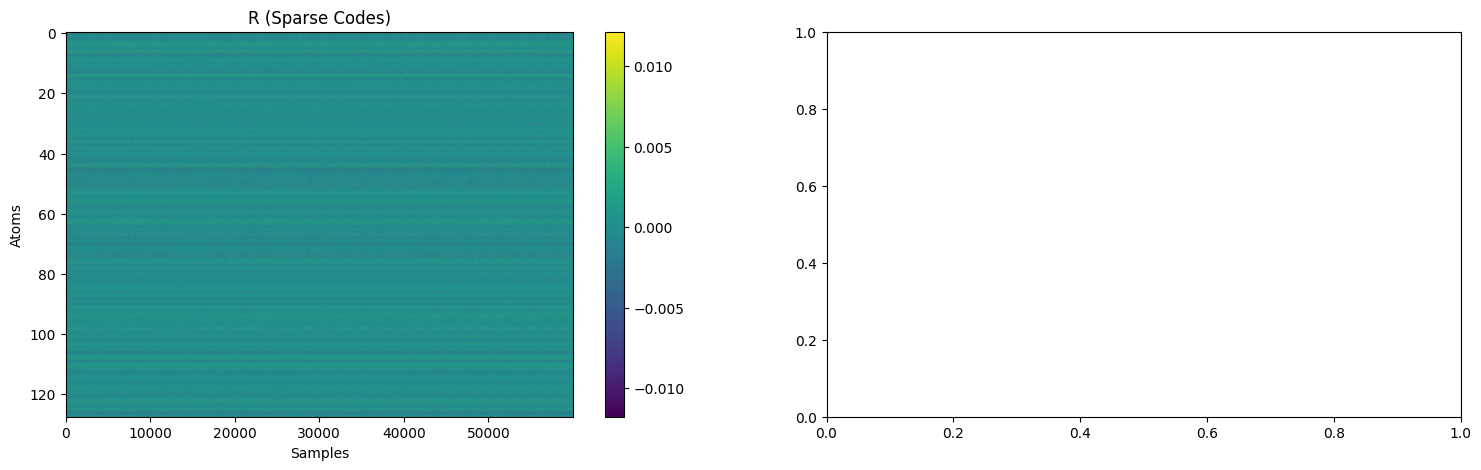

In [35]:

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# Sparse codes
im0 = axes[0].imshow(S.cpu().numpy(), aspect="auto", cmap="viridis")
axes[0].set_title("R (Sparse Codes)")
axes[0].set_xlabel("Samples")
axes[0].set_ylabel("Atoms")
plt.colorbar(im0, ax=axes[0])



In [36]:
S

tensor([[-0.0054, -0.0015, -0.0015,  ..., -0.0053, -0.0048, -0.0004],
        [-0.0033, -0.0002, -0.0027,  ..., -0.0001,  0.0002,  0.0012],
        [-0.0015, -0.0019, -0.0028,  ..., -0.0027, -0.0010,  0.0014],
        ...,
        [ 0.0010, -0.0011, -0.0023,  ..., -0.0006,  0.0014, -0.0009],
        [-0.0010, -0.0015, -0.0013,  ..., -0.0042, -0.0030, -0.0025],
        [ 0.0012,  0.0014, -0.0009,  ...,  0.0008,  0.0001, -0.0011]],
       device='cuda:0')

In [37]:
X_np = X_dict[0].detach().cpu().numpy()
D_np = D.detach().cpu().numpy()
R_np = S.detach().cpu().numpy()

errors, sparsity = compute_metrics(
    X_np,
    D_np,
    R_np,
    name="SCA"
)


===== SCA =====
Avg error: 3.0594
Std error: 0.8323
Avg sparsity: 110.47
Sparsity ratio: 0.8630


In [25]:
X_np

array([[ 6.4489534e-03,  1.4991458e-03,  5.6707766e-03, ...,
         3.1784184e-03,  9.1814523e-04,  2.8641953e-03],
       [ 2.4420056e-03,  1.2701459e-03,  5.9259539e-03, ...,
         7.5559062e-03,  7.1310080e-03, -2.4367492e-03],
       [ 1.4363553e-03,  1.8792602e-03,  4.5698509e-03, ...,
        -2.5002863e-03,  2.2637930e-03,  1.5485403e-03],
       ...,
       [-1.2897188e-03,  1.3599228e-03, -1.8447109e-04, ...,
         2.2945348e-03,  7.5549195e-03,  1.1253323e-03],
       [-4.1912968e-04,  9.6881599e-04,  9.4799809e-03, ...,
         9.2482107e-04, -9.8331808e-04, -9.9972698e-05],
       [-5.2784136e-03, -1.5218118e-03, -6.0896142e-03, ...,
         2.3552238e-04,  4.2137722e-03, -1.5976154e-03]],
      shape=(128, 60000), dtype=float32)

In [26]:
D_np @ R_np - X_np

array([[ 3.9293431e-05, -1.1605397e-04, -6.6954177e-05, ...,
        -1.2761215e-04,  2.9604166e-04, -2.1436485e-05],
       [ 3.1467690e-04,  3.9878883e-05,  1.9071857e-04, ...,
        -9.7142067e-05, -1.1874968e-04, -1.6548485e-04],
       [-1.8557976e-04,  1.6658683e-04,  1.8989481e-04, ...,
         2.1856301e-04, -3.7964201e-05, -2.7887174e-05],
       ...,
       [-2.3070257e-05, -8.9682522e-05, -1.9095540e-04, ...,
         1.0997523e-05, -1.9784365e-04,  1.8944149e-05],
       [ 1.1857605e-04, -3.4592813e-06,  2.2538006e-05, ...,
        -4.9761613e-05, -8.2737301e-05, -1.1653508e-04],
       [-1.2231059e-04,  1.5441957e-04, -5.5944547e-06, ...,
         2.2211544e-04, -6.7185145e-05, -5.5577606e-05]],
      shape=(128, 60000), dtype=float32)